In [43]:
import os
import random
import glob

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

from sklearn.tree import DecisionTreeClassifier, plot_tree

sns.set(style="whitegrid", palette="muted", font_scale=1.2)
os.environ["OMP_NUM_THREADS"] = "4"


In [44]:
# -----------------------------
# 1. ACH FILE GENERATOR
# -----------------------------

ROUTING_OPTIONS = [
    "02100002",  # NY
    "12100035",  # CA
    "09100001",  # Midwest
    "06100010",  # Southeast
]

N_FILES = 5
RECORDS_PER_FILE = 200

os.makedirs("data", exist_ok=True)

def make_entry_detail():
    # Choose routing region
    routing = random.choice(ROUTING_OPTIONS)
    check_digit = str(sum(int(d) for d in routing) % 10)
    dfi = routing + check_digit  # 9 chars

    # Account number: 17 chars, fixed
    account = str(random.randint(0, 99999999999999999)).zfill(17)

    # Inject structure:
    # - credits tend to be larger amounts
    # - certain routing regions have systematically higher/lower amounts
    is_credit = random.random() < 0.5
    if is_credit:
        transaction_code = random.choice(["22", "23", "24"])  # credits
        base_amount = random.randint(5000, 50000)
    else:
        transaction_code = random.choice(["27", "28", "29"])  # debits
        base_amount = random.randint(50, 5000)

    # Routing-based scaling
    if routing.startswith("12"):      # West
        base_amount = int(base_amount * 1.5)
    elif routing.startswith("09"):    # Midwest
        base_amount = int(base_amount * 0.7)
    elif routing.startswith("06"):    # Southeast
        base_amount = int(base_amount * 1.2)

    amount = max(1, min(base_amount, 9999999999))  # clamp
    amount_str = str(amount).zfill(10)             # 10 chars

    # Individual ID: 15 chars
    individual_id = str(random.randint(0, 999999999999999)).zfill(15)

    # Name: 22 chars
    individual_name = random.choice(["JOHN DOE", "JANE SMITH", "ALICE BROWN"]).ljust(22)

    # Discretionary data: 2 chars
    discretionary = "  "

    # Addenda indicator: 1 char
    addenda = "0"

    # Trace number: 15 chars
    trace = "12345678" + str(random.randint(0, 99999999)).zfill(8)

    line = (
        "6" +                 # 1
        transaction_code +    # 2
        dfi +                 # 9
        account +             # 17
        amount_str +          # 10
        individual_id +       # 15
        individual_name +     # 22
        discretionary +       # 2
        addenda +             # 1
        trace                 # 15
    )

    # Guarantee exactly 94 characters
    line = line[:94]
    return line

def write_ach_files():
    for i in range(1, N_FILES + 1):
        path = os.path.join("data", f"ach{i}.txt")
        with open(path, "w", newline="") as fh:
            # Simple file header + batch header (dummy, not parsed)
            fh.write("101 1 SIMPLE ACH FILE HEADER DUMMY LINE.........................\n")
            fh.write("5200TEST BATCH HEADER DUMMY LINE...............................\n")
            for _ in range(RECORDS_PER_FILE):
                fh.write(make_entry_detail() + "\n")

write_ach_files()


In [45]:

# -----------------------------
# 2. PARSER
# -----------------------------

records = []

for f in glob.glob("data/*.txt"):
    with open(f, "r") as fh:
        for line in fh:
            line = line.rstrip("\r\n")

            # skip malformed lines
            if len(line) < 94:
                continue

            # force to exactly 94 chars
            line = line[:94]

            # only entry detail records
            if not line.startswith("6"):
                continue

            transaction_code = line[1:3]
            dfi = line[3:12]
            routing = dfi[:8]
            account = line[12:29].strip()

            amount_str = line[29:39].strip()
            if not amount_str.isdigit():
                continue
            amount = int(amount_str)

            debit_credit_flag = (
                "C" if transaction_code in ["20", "21", "22", "23", "24", "28"]
                else "D"
            )

            records.append({
                "routing": routing,
                "account": account,
                "amount": amount,
                "debit_credit_flag": debit_credit_flag
            })

df = pd.DataFrame(records)
print(df.head())
print(df.shape)


    routing            account  amount debit_credit_flag
0  06100010  48463886403074296   45994                 C
1  02100002  29872588970565732    3740                 D
2  12100035  60083108076745510    9564                 C
3  12100035  40065741713120482   72057                 C
4  12100035  83875959564693513    3621                 D
(1014, 4)


In [46]:
# -----------------------------
# 3. FEATURE CLEANUP
# -----------------------------

df["amount_scaled"] = StandardScaler().fit_transform(df[["amount"]])
df["routing_region"] = df["routing"].str[:2].astype(int)
df["is_credit"] = (df["debit_credit_flag"] == "C").astype(int)

X = df[["amount_scaled", "routing_region", "is_credit"]]


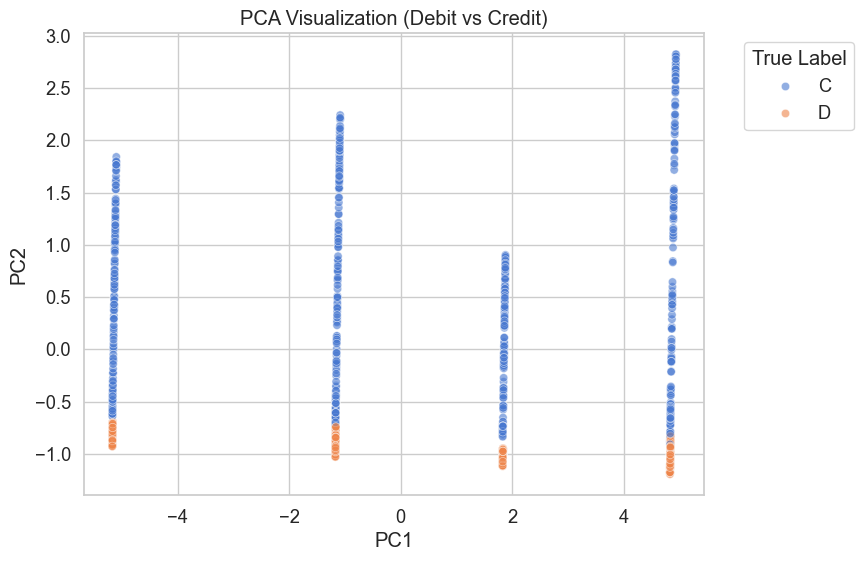

In [47]:

# -----------------------------
# 4. PCA
# -----------------------------

pca = PCA(n_components=2)
pcs = pca.fit_transform(X)

df["PC1"] = pcs[:, 0]
df["PC2"] = pcs[:, 1]

plt.figure(figsize=(8, 6))
sns.scatterplot(x="PC1", y="PC2", hue="debit_credit_flag", data=df, alpha=0.6)
plt.title("PCA Visualization (Debit vs Credit)")
plt.legend(title="True Label", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.show()



C:\Users\ramya\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


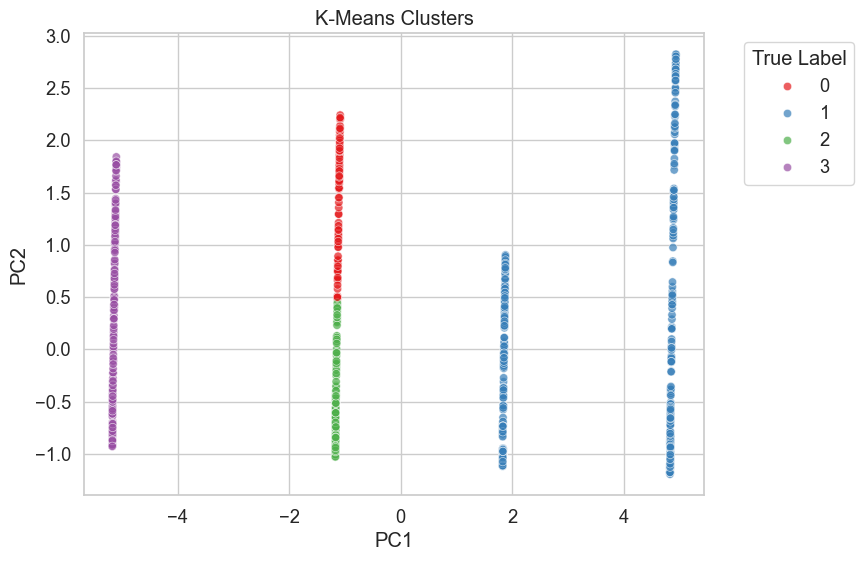

In [48]:
# -----------------------------
# 5. K-MEANS
# -----------------------------

kmeans = KMeans(n_clusters=4, random_state=42, n_init="auto")
df["Cluster"] = kmeans.fit_predict(X)

plt.figure(figsize=(8, 6))
sns.scatterplot(x="PC1", y="PC2", hue="Cluster", data=df, palette="Set1", alpha=0.7)
plt.title("K-Means Clusters")
plt.legend(title="True Label", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()


              precision    recall  f1-score   support

           C       0.99      0.96      0.97       206
           D       0.92      0.98      0.95        99

    accuracy                           0.96       305
   macro avg       0.95      0.97      0.96       305
weighted avg       0.97      0.96      0.96       305

[[197   9]
 [  2  97]]


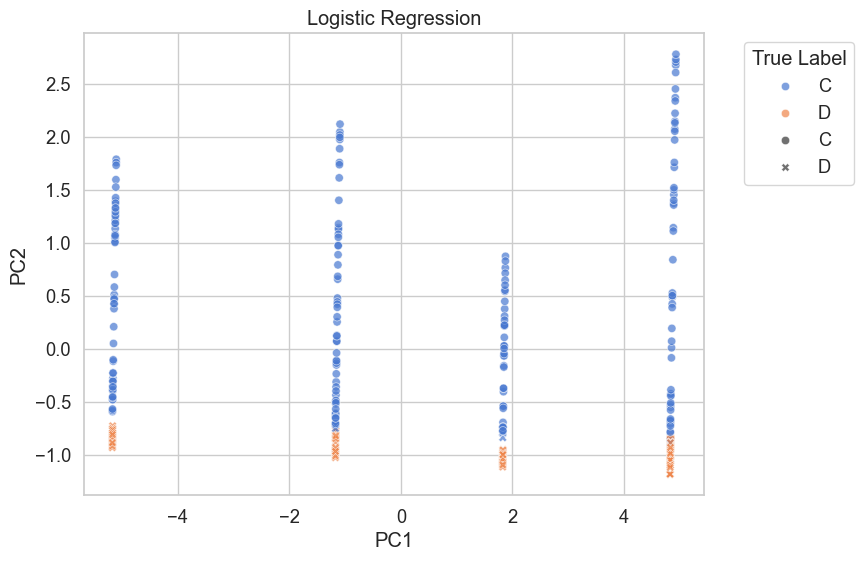

In [49]:
# -----------------------------
# 6. LOGISTIC REGRESSION
# -----------------------------

X_train, X_test, y_train, y_test = train_test_split(
    df[["PC1", "PC2"]],
    df["debit_credit_flag"],
    test_size=0.3,
    random_state=42,
    stratify=df["debit_credit_flag"]
)

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)

y_pred = log_reg.predict(X_test)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_test["PC1"], y=X_test["PC2"], hue=y_test, style=y_pred, alpha=0.7)
plt.title("Logistic Regression")
plt.legend(title="True Label", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.show()



Decision Tree Classification Report:
              precision    recall  f1-score   support

           C       0.99      0.96      0.98       206
           D       0.92      0.99      0.96        99

    accuracy                           0.97       305
   macro avg       0.96      0.98      0.97       305
weighted avg       0.97      0.97      0.97       305

[[198   8]
 [  1  98]]


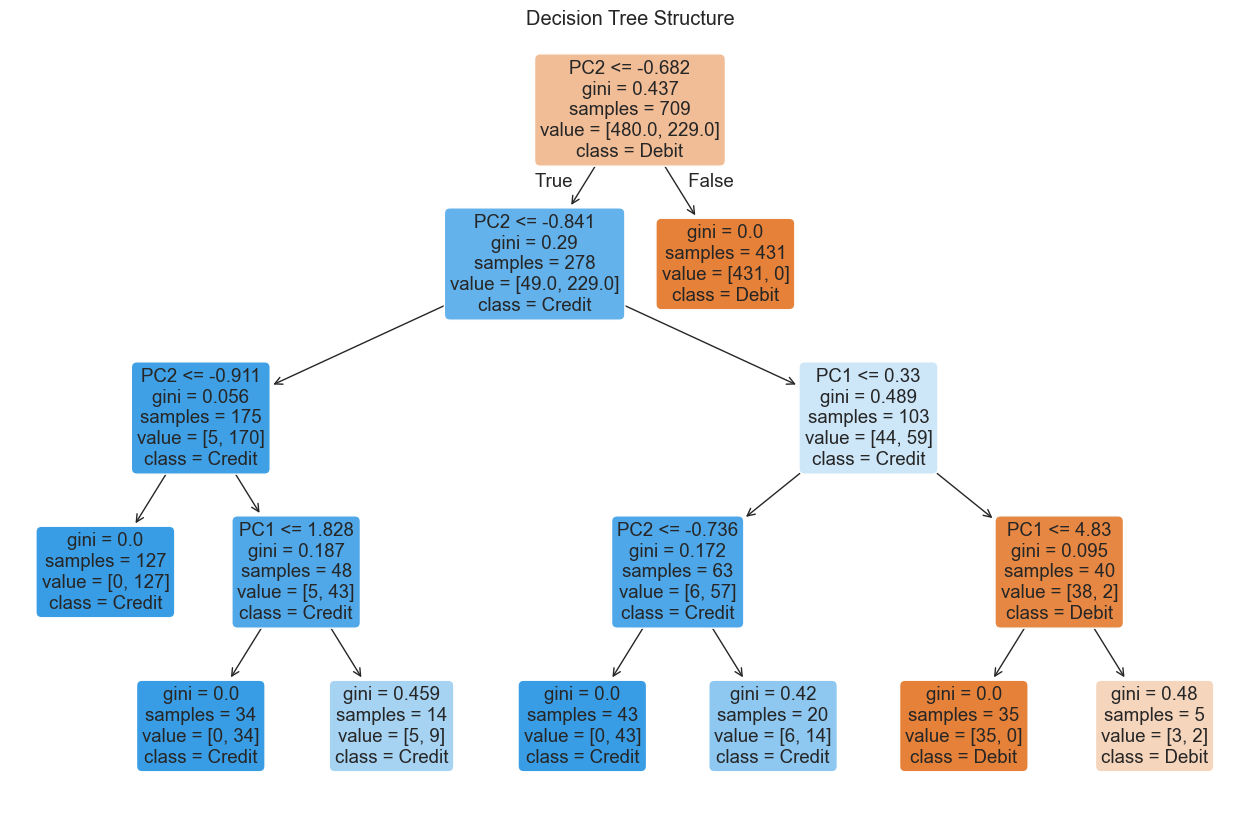

In [50]:
# -----------------------------
# 7. DECISION TREE CLASSIFIER
# -----------------------------

dt = DecisionTreeClassifier(
    max_depth=4,
    min_samples_leaf=5,
    random_state=42
)

dt.fit(X_train, y_train)
y_dt_pred = dt.predict(X_test)

print("Decision Tree Classification Report:")
print(classification_report(y_test, y_dt_pred))
print(confusion_matrix(y_test, y_dt_pred))

plt.figure(figsize=(16, 10))
plot_tree(
    dt,
    feature_names=["PC1", "PC2"],
    class_names=["Debit", "Credit"],
    filled=True,
    rounded=True
)
plt.title("Decision Tree Structure")
plt.show()


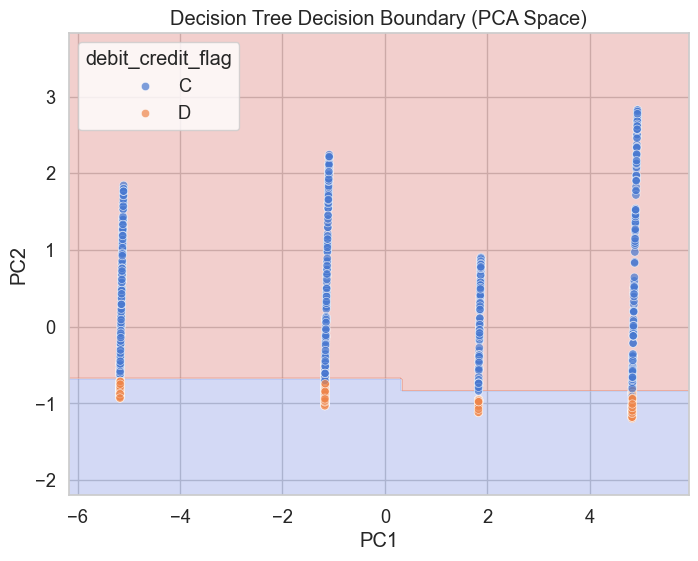

In [51]:
# Create mesh grid
x_min, x_max = df["PC1"].min() - 1, df["PC1"].max() + 1
y_min, y_max = df["PC2"].min() - 1, df["PC2"].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

# Predict on grid
grid = pd.DataFrame(
    np.c_[xx.ravel(), yy.ravel()],
    columns=["PC1", "PC2"]
)

Z = dt.predict(grid)

# Convert "C"/"D" → 1/0 for contourf
Z_numeric = (Z == "C").astype(int)
Z_numeric = Z_numeric.reshape(xx.shape)

plt.figure(figsize=(8, 6))

# Decision regions
plt.contourf(xx, yy, Z_numeric, alpha=0.25, cmap="coolwarm")

# Actual points
sns.scatterplot(
    x=df["PC1"], y=df["PC2"],
    hue=df["debit_credit_flag"],
    alpha=0.7
)

plt.title("Decision Tree Decision Boundary (PCA Space)")
plt.show()


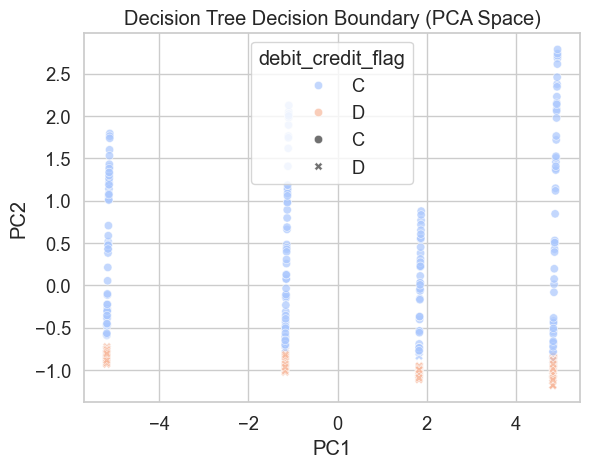

C:\Users\ramya\AppData\Local\Temp\ipykernel_2232\1510755817.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


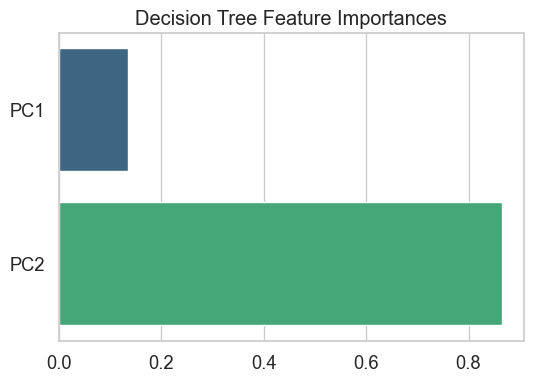

In [52]:
# Actual points


sns.scatterplot(
    x=X_test["PC1"],
    y=X_test["PC2"],
    hue=y_test,
    style=y_pred,
    palette="coolwarm",
    alpha=0.7
)

plt.title("Decision Tree Decision Boundary (PCA Space)")
plt.show()

plt.figure(figsize=(6,4))
sns.barplot(
    x=dt.feature_importances_,
    y=["PC1", "PC2"],
    palette="viridis"
)
plt.title("Decision Tree Feature Importances")
plt.show()

In [53]:
import os

def make_consolidated_ach(df, output_path="consolidated_ach.txt"):
    # Ensure directory exists
    os.makedirs(os.path.dirname(output_path) or ".", exist_ok=True)

    samples = []

    # 1. One sample per routing region
    for region in df["routing_region"].unique():
        samples.append(df[df["routing_region"] == region].sample(1, random_state=42))

    # 2. One sample per debit/credit type
    for dc in df["debit_credit_flag"].unique():
        samples.append(df[df["debit_credit_flag"] == dc].sample(1, random_state=42))

    # 3. One sample per amount quartile
    df["amount_bin"] = pd.qcut(df["amount"], 4, labels=False, duplicates="drop")
    for q in df["amount_bin"].unique():
        samples.append(df[df["amount_bin"] == q].sample(1, random_state=42))

    # 4. One sample per K-Means cluster (already computed)
    for c in df["Cluster"].unique():
        samples.append(df[df["Cluster"] == c].sample(1, random_state=42))

    # Combine and dedupe
    consolidated = pd.concat(samples).drop_duplicates()

    # --- Write ACH file ---
    with open(output_path, "w") as fh:
        fh.write("101 CONSOLIDATED ACH FILE HEADER.................................\n")
        fh.write("5200CONSOLIDATED BATCH HEADER....................................\n")

        for _, row in consolidated.iterrows():
            # Rebuild a valid 94-char entry detail record
            routing = row["routing"]
            check_digit = str(sum(int(d) for d in routing) % 10)
            dfi = routing + check_digit

            account = row["account"].ljust(17)[:17]
            amount_str = str(row["amount"]).zfill(10)

            individual_id = "000000000000000".ljust(15)
            individual_name = "CONSOLIDATED".ljust(22)

            discretionary = "  "
            addenda = "0"

            # Use credit/debit flag to choose transaction code
            if row["debit_credit_flag"] == "C":
                transaction_code = "22"
            else:
                transaction_code = "27"

            trace = "99999999" + str(random.randint(0, 99999999)).zfill(8)

            line = (
                "6" +
                transaction_code +
                dfi +
                account +
                amount_str +
                individual_id +
                individual_name +
                discretionary +
                addenda +
                trace
            )

            fh.write(line[:94] + "\n")

        fh.write("8200000000000000000000000000000000000000000000000000000000000000\n")
        fh.write("9000001000001000000000000000000000000000000000000000000000000000\n")

    print(f"Consolidated ACH file written to: {output_path}")

make_consolidated_ach(df, "data/consolidated_ach.txt")


Consolidated ACH file written to: data/consolidated_ach.txt


In [54]:
# ============================================================
# 7. DECISION TREE + DECISION BOUNDARY
# ============================================================

from sklearn.tree import DecisionTreeClassifier, plot_tree

# Train the tree
dt = DecisionTreeClassifier(
    max_depth=4,
    min_samples_leaf=5,
    random_state=42
)
dt.fit(X_train, y_train)

# Predictions
y_dt_pred = dt.predict(X_test)

print("Decision Tree Classification Report:")
print(classification_report(y_test, y_dt_pred))
print(confusion_matrix(y_test, y_dt_pred))

Decision Tree Classification Report:
              precision    recall  f1-score   support

           C       0.99      0.96      0.98       206
           D       0.92      0.99      0.96        99

    accuracy                           0.97       305
   macro avg       0.96      0.98      0.97       305
weighted avg       0.97      0.97      0.97       305

[[198   8]
 [  1  98]]


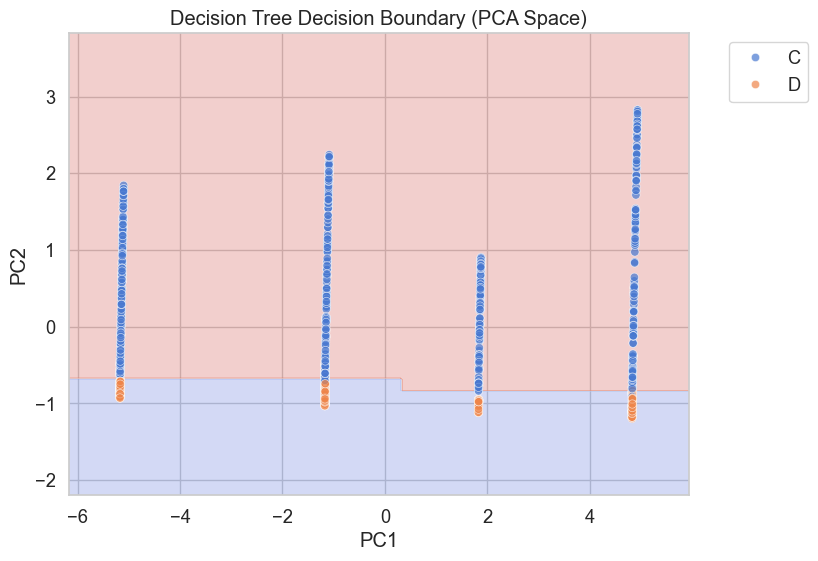

In [55]:
# -----------------------------
# Decision Boundary in PCA Space
# -----------------------------

# Create mesh grid
x_min, x_max = df["PC1"].min() - 1, df["PC1"].max() + 1
y_min, y_max = df["PC2"].min() - 1, df["PC2"].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

# Predict on grid
grid = pd.DataFrame(
    np.c_[xx.ravel(), yy.ravel()],
    columns=["PC1", "PC2"]
)

Z = dt.predict(grid)


# Convert "C"/"D" → numeric for contourf
Z_numeric = (Z == "C").astype(int).reshape(xx.shape)

plt.figure(figsize=(8, 6))

# Decision regions
plt.contourf(xx, yy, Z_numeric, alpha=0.25, cmap="coolwarm")

# Actual points
sns.scatterplot(
    x=df["PC1"],
    y=df["PC2"],
    hue=df["debit_credit_flag"],
    alpha=0.7
)

plt.title("Decision Tree Decision Boundary (PCA Space)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

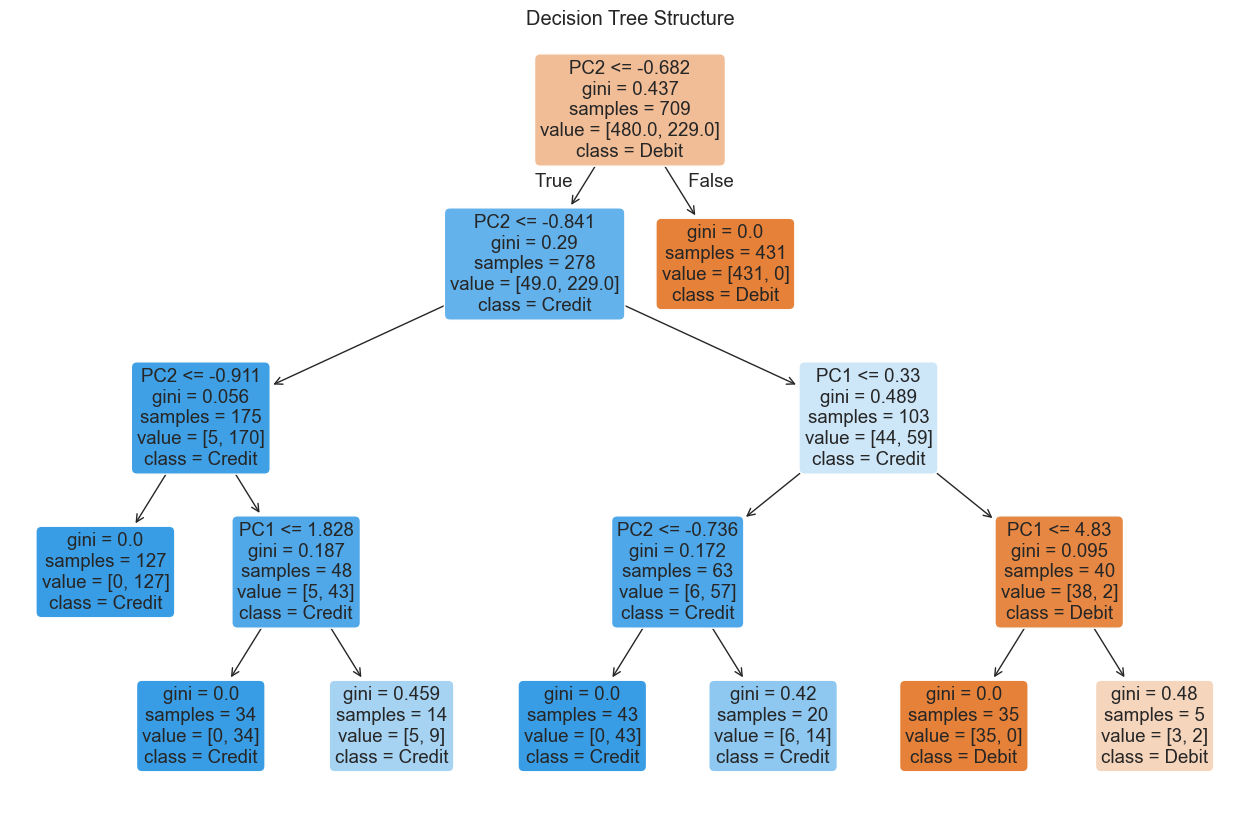

In [56]:
# -----------------------------
# Visualize the Tree Structure
# -----------------------------

plt.figure(figsize=(16, 10))
plot_tree(
    dt,
    feature_names=["PC1", "PC2"],
    class_names=["Debit", "Credit"],
    filled=True,
    rounded=True
)
plt.title("Decision Tree Structure")
plt.show()


=== Evaluating Consolidated ACH File ===



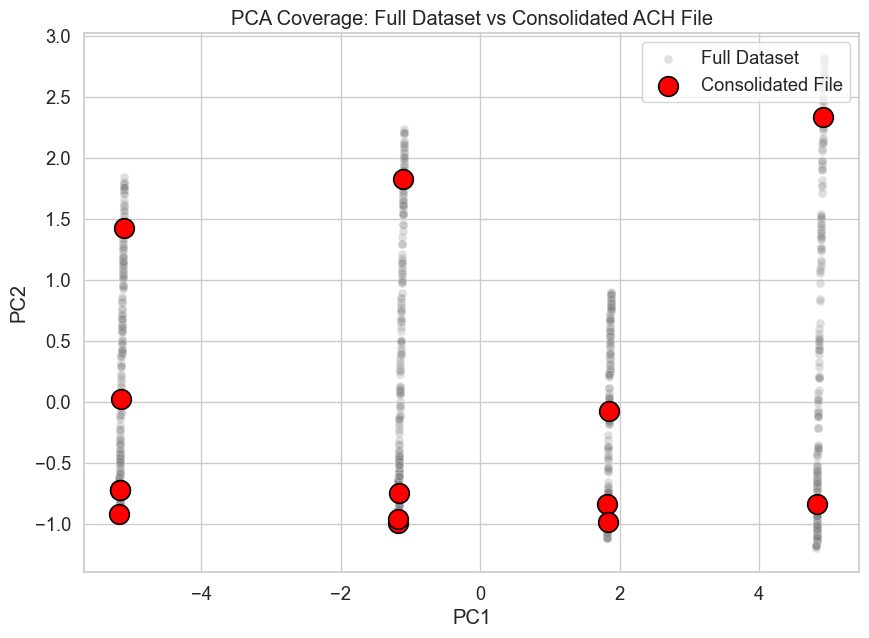

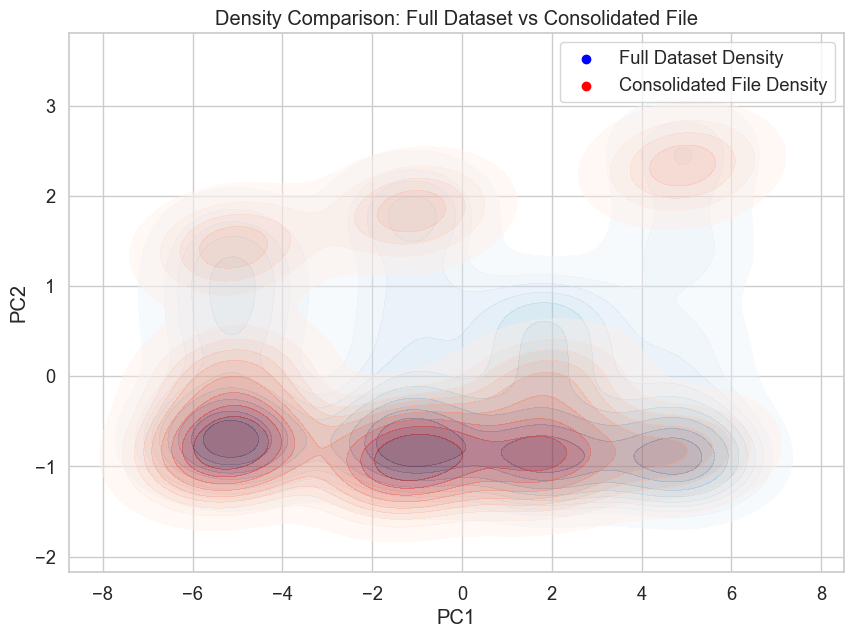

In [57]:
# ============================================================
# EVALUATION + PCA OVERLAY PLOT
# ============================================================

from scipy.stats import ks_2samp
from sklearn.neighbors import NearestNeighbors

def parse_consolidated_file(path):
    """Parse the consolidated ACH file into a DataFrame."""
    rows = []
    with open(path, "r") as fh:
        for line in fh:
            line = line.rstrip("\n")
            if len(line) < 94 or not line.startswith("6"):
                continue

            routing = line[3:11][:8]
            amount = int(line[29:39])
            dc = "C" if line[1:3] in ["20","21","22","23","24","28"] else "D"

            rows.append({
                "routing": routing,
                "amount": amount,
                "debit_credit_flag": dc
            })

    return pd.DataFrame(rows)


def evaluate_consolidation(df, consolidated_path="data/consolidated_ach.txt"):
    print("\n=== Evaluating Consolidated ACH File ===\n")

    # -----------------------------
    # Load consolidated file
    # -----------------------------
    con_df = parse_consolidated_file(consolidated_path)

    # Feature engineering to match full dataset
    con_df["routing_region"] = con_df["routing"].str[:2].astype(int)
    con_df["is_credit"] = (con_df["debit_credit_flag"] == "C").astype(int)

    # Scale amount using the SAME scaler as full dataset
    scaler = StandardScaler().fit(df[["amount"]])
    con_df["amount_scaled"] = scaler.transform(con_df[["amount"]])

    # PCA transform using the SAME PCA model
    con_pcs = pca.transform(con_df[["amount_scaled", "routing_region", "is_credit"]])
    con_df["PC1"] = con_pcs[:, 0]
    con_df["PC2"] = con_pcs[:, 1]

    # Assign clusters using the SAME KMeans model
    con_df["Cluster"] = kmeans.predict(con_df[["amount_scaled", "routing_region", "is_credit"]])

      # ============================================================
    # 1. PCA OVERLAY PLOT
    # ============================================================

    plt.figure(figsize=(10, 7))

    # Full dataset cloud
    sns.scatterplot(
        x=df["PC1"], y=df["PC2"],
        alpha=0.25, s=40, color="gray",
        label="Full Dataset"
    )

    # Consolidated file points
    sns.scatterplot(
        x=con_df["PC1"], y=con_df["PC2"],
        s=200, color="red",
        edgecolor="black", linewidth=1.2,
        label="Consolidated File"
    )

    plt.title("PCA Coverage: Full Dataset vs Consolidated ACH File")
    plt.legend(loc="upper right")
    plt.show()

    # ============================================================
    # 2. DENSITY COMPARISON PLOT
    # ============================================================

    plt.figure(figsize=(10, 7))

    sns.kdeplot(
    x=df["PC1"], y=df["PC2"],
    fill=True, cmap="Blues",
    alpha=0.4, thresh=0.05
    )

    sns.kdeplot(
    x=con_df["PC1"], y=con_df["PC2"],
    fill=True, cmap="Reds",
    alpha=0.4, thresh=0.05,
    bw_adjust=0.5
    )

# Dummy points for legend
    plt.scatter([], [], color="blue", label="Full Dataset Density")
    plt.scatter([], [], color="red", label="Consolidated File Density")

    plt.title("Density Comparison: Full Dataset vs Consolidated File")
    plt.legend(loc="upper right")
    plt.show()



# Run evaluation
con_df = evaluate_consolidation(df)
    
  